# PyTorch Dual Flow Notebook

## Embedded code

## Embedded code instead of imports

In [1]:
import os
import sys
from pathlib import Path
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import torch
from ipywidgets import interact

sys.path.insert(0, str(Path.cwd().parent))
from res.plot_lib import *
from pysrc.ssl_disentangling import (
    ActivationNormalization,
    AdditiveCoupling,
    CheckerBoardMask,
    CheckerBoardPermutation,
    FlowModel,
    Reflection,
    SupervisedFactorLoss,
    build_flow_layers,
    paired_batch_generator,
    sample_curve_data,
    set_global_seed,
)

torch.set_default_dtype(torch.float64)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
save_plots = True
output_dir = os.path.join("output_04-spiral_classification", "pytorch_dual_disentangle")
os.makedirs(output_dir, exist_ok=True)
set_default()

## Create Base Spiral Data

In [ ]:
seed = 12345
torch.manual_seed(seed)
np.random.seed(seed)
N = 4096  # num_samples_per_class
n = 2     # input dimensions
K = 1     # num_classes
d = 100   # num_hidden_units
turns = 1  # number of spiral turns (set to 1)

In [ ]:
t = torch.linspace(0, 1, N)
amplitude = 0.8 * t + 0.2
X = list()
y = list()
for k in range(K):
    theta = (turns * t + k) * 2 * np.pi / K + 0.2 * torch.randn(N)
    X.append(torch.stack((amplitude * theta.sin(), amplitude * theta.cos()), dim=1))
    y.append(torch.zeros(N, dtype=torch.long).fill_(k))
X = torch.cat(X)
y = torch.cat(y)

print("Shapes:")
print("X:", tuple(X.size()))
print("y:", tuple(y.size()))

Shapes:
X: (4096, 2)
y: (4096,)


In [5]:
from matplotlib import colors as mpl_colors

X_np = X.cpu().numpy()
y_np = y.cpu().numpy()
r = np.sqrt(X_np[:, 0] ** 2 + X_np[:, 1] ** 2)
r_min, r_max = r.min(), r.max()
r_norm = (r - r_min) / (r_max - r_min + 1e-9)
K = int(y.max() + 1) if isinstance(y, torch.Tensor) else int(np.max(y) + 1)
hues = np.arange(K) / float(K)
v_min, v_max = 0.05, 0.95
values = v_min + (v_max - v_min) * r_norm
saturation = 0.9
h = hues[y_np]
s = np.full_like(h, saturation, dtype=float)
v = values
hsv = np.stack([h, s, v], axis=1)
rgb = mpl_colors.hsv_to_rgb(hsv)
point_colors = rgb

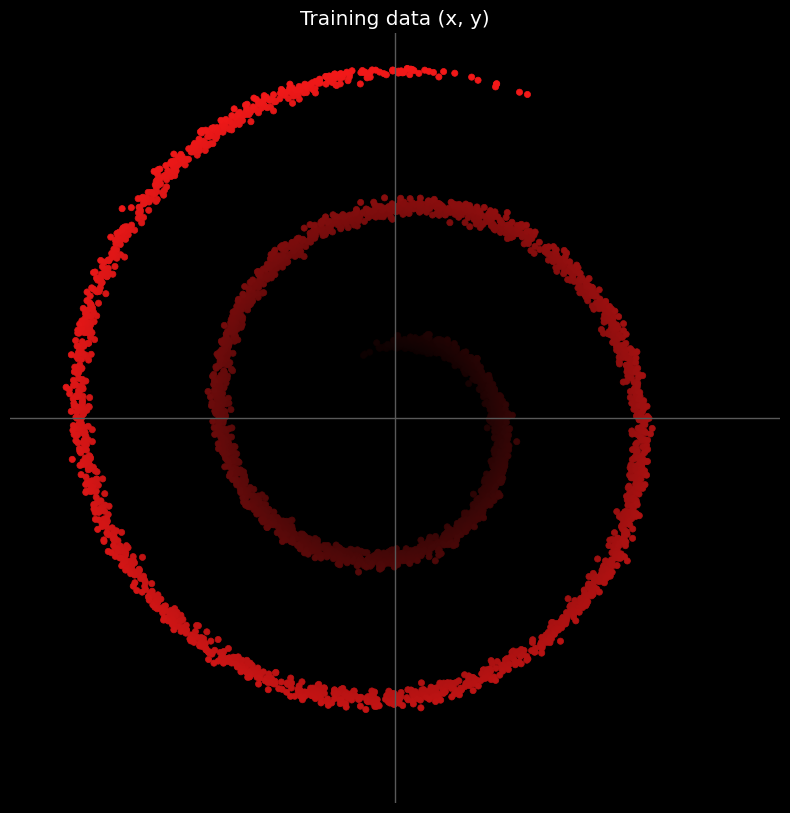

In [6]:
plot_data(X, y, point_colors=point_colors)
if save_plots:
    plt.savefig(os.path.join(output_dir, "data.png"), bbox_inches='tight')

## Prepare Dataset A

In [7]:
num_samples = 4096
batch_size = 128
num_dims = 3

# The underlying physics: Liquid Level (0 to 1)
param_values = np.linspace(0, 1, num_samples)

# --- Modality A: AUDIO SPACE (Pitch, Resonance, Splashing Noise) ---
pitch = 1.0 / (1.2 - param_values)        # Nonlinear pitch increase
resonance = np.sin(param_values * np.pi)  # Timbre envelope
splashing_noise = np.random.normal(0, 0.1, num_samples) # Unique Audio Noise

data_a_unrot = np.stack([pitch, resonance, splashing_noise], axis=1)
data_a_unrot = (data_a_unrot - data_a_unrot.mean(axis=0)) / data_a_unrot.std(axis=0)

# Apply Arbitrary 3D Rotation to entangle
theta_a = np.pi / 3
rot_y_a = np.array([[np.cos(theta_a), 0, np.sin(theta_a)], 
                    [0, 1, 0], 
                    [-np.sin(theta_a), 0, np.cos(theta_a)]])
rot_z_a = np.array([[np.cos(theta_a), -np.sin(theta_a), 0], 
                    [np.sin(theta_a), np.cos(theta_a), 0], 
                    [0, 0, 1]])
data_a = data_a_unrot @ rot_y_a @ rot_z_a

print("Dataset A structure:")
print(f"data_a shape: {data_a.shape}")
print(f"param_values shape: {param_values.shape}")


Dataset A structure:
data_a shape: (4096, 3)
param_values shape: (4096,)


## Prepare Dataset B

In [8]:
# --- Modality B: VIDEO SPACE (Height, Perspective Width, Lighting Noise) ---
visual_height = param_values * 2.0 - 1.0               # Linear rise
water_width = param_values ** 2                        # Conical perspective
lighting_noise = np.random.choice([-1.0, 1.0], num_samples) + np.random.normal(0, 0.05, num_samples)

data_b_unrot = np.stack([visual_height, water_width, lighting_noise], axis=1)
data_b_unrot = (data_b_unrot - data_b_unrot.mean(axis=0)) / data_b_unrot.std(axis=0)

# Apply different 3D Rotation to entangle
theta_b = -np.pi / 4
rot_x_b = np.array([[1, 0, 0], 
                    [0, np.cos(theta_b), -np.sin(theta_b)], 
                    [0, np.sin(theta_b), np.cos(theta_b)]])
data_b = data_b_unrot @ rot_x_b @ rot_z_a

def water_batch_generator(da, db, bs):
    while True:
        idx = np.random.choice(len(da), bs, replace=False)
        yield (da[idx], db[idx]), None

batch_size = 128
pair_gen = water_batch_generator(data_a, data_b, batch_size)
(batch_a, batch_b), corr_target = next(pair_gen)

print("batch_a shape:", batch_a.shape)
print("batch_b shape:", batch_b.shape)


batch_a shape: (128, 3)
batch_b shape: (128, 3)


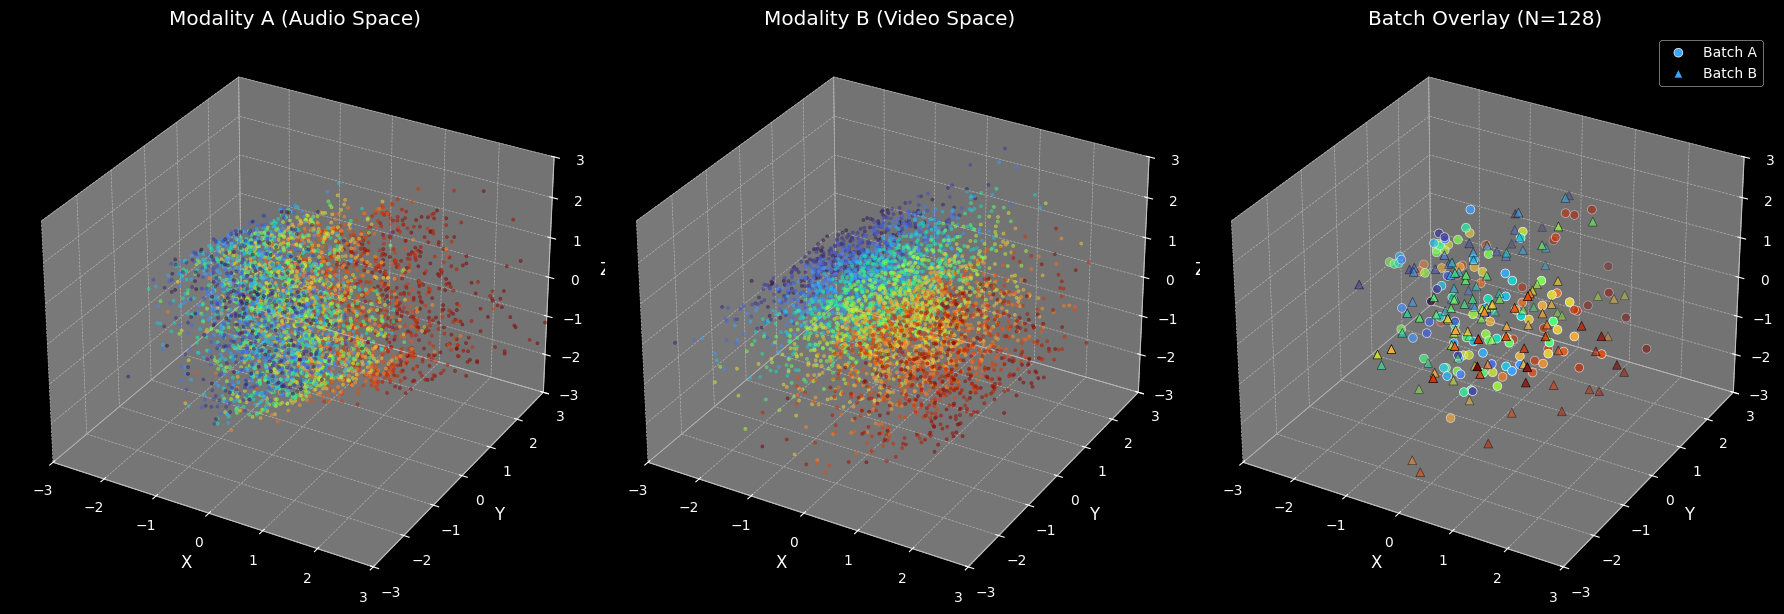

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Ground Truth / Shared Manifold
# ==========================================
num_samples = 4096
np.random.seed(42) # For reproducibility

# u: Liquid Level, v: Pouring Position
u = np.random.uniform(0, 1, num_samples)
v = np.random.uniform(-1, 1, num_samples)

# ==========================================
# 2. Modality A (Audio Space - 3D)
# ==========================================
# Dim 1: Nonlinear rise in pitch
dim1_a = 1.0 / (1.2 - u)
# Dim 2: Linear panning
dim2_a = v
# Dim 3: Splashing noise
dim3_a = np.random.normal(0, 0.15, num_samples)

data_a_raw = np.column_stack((dim1_a, dim2_a, dim3_a))

# Standardize
data_a_std = (data_a_raw - np.mean(data_a_raw, axis=0)) / np.std(data_a_raw, axis=0)

# 3D Twisting Rotation for Modality A: Ry(pi/4) * Rz(pi/3)
theta_y_a = np.pi / 4
theta_z_a = np.pi / 3

Ry_a = np.array([
    [np.cos(theta_y_a), 0, np.sin(theta_y_a)],
    [0, 1, 0],
    [-np.sin(theta_y_a), 0, np.cos(theta_y_a)]
])

Rz_a = np.array([
    [np.cos(theta_z_a), -np.sin(theta_z_a), 0],
    [np.sin(theta_z_a), np.cos(theta_z_a), 0],
    [0, 0, 1]
])

rot_matrix_a = Ry_a @ Rz_a
data_a = data_a_std @ rot_matrix_a.T

# ==========================================
# 3. Modality B (Video Space - 3D)
# ==========================================
# Dim 1: Visual height
dim1_b = u
# Dim 2: Expanding width
dim2_b = v * (0.5 + u)
# Dim 3: Lighting noise
dim3_b = np.random.normal(0, 0.15, num_samples)

data_b_raw = np.column_stack((dim1_b, dim2_b, dim3_b))

# Standardize
data_b_std = (data_b_raw - np.mean(data_b_raw, axis=0)) / np.std(data_b_raw, axis=0)

# DIFFERENT 3D Twisting Rotation for Modality B: Rx(-pi/3) * Ry(pi/6)
theta_x_b = -np.pi / 3
theta_y_b = np.pi / 6

Rx_b = np.array([
    [1, 0, 0],
    [0, np.cos(theta_x_b), -np.sin(theta_x_b)],
    [0, np.sin(theta_x_b), np.cos(theta_x_b)]
])

Ry_b = np.array([
    [np.cos(theta_y_b), 0, np.sin(theta_y_b)],
    [0, 1, 0],
    [-np.sin(theta_y_b), 0, np.cos(theta_y_b)]
])

rot_matrix_b = Rx_b @ Ry_b
data_b = data_b_std @ rot_matrix_b.T

# ==========================================
# 4. Batch Generator
# ==========================================
def water_batch_generator(da, db, u_true, batch_size):
    """
    Yields random aligned mini-batches without replacement.
    Using `u_true` as the dummy target so we can properly color the batch plots later.
    """
    n = da.shape[0]
    indices = np.random.permutation(n)
    
    for i in range(0, n, batch_size):
        batch_idx = indices[i:i + batch_size]
        yield da[batch_idx], db[batch_idx], u_true[batch_idx]

# Test it by extracting one batch of 128 samples
gen = water_batch_generator(data_a, data_b, u, 128)
batch_a, batch_b, target_u = next(gen)

# ==========================================
# 5. 3D Plotting
# ==========================================
fig = plt.figure(figsize=(18, 6))

# Subplot 1: Data A
ax1 = fig.add_subplot(131, projection='3d')
p1 = ax1.scatter(data_a[:, 0], data_a[:, 1], data_a[:, 2], 
                 c=u, cmap='turbo', s=5, alpha=0.5)
ax1.set_xlim([-3, 3]); ax1.set_ylim([-3, 3]); ax1.set_zlim([-3, 3])
ax1.set_title('Modality A (Audio Space)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# Subplot 2: Data B
ax2 = fig.add_subplot(132, projection='3d')
p2 = ax2.scatter(data_b[:, 0], data_b[:, 1], data_b[:, 2], 
                 c=u, cmap='turbo', s=5, alpha=0.5)
ax2.set_xlim([-3, 3]); ax2.set_ylim([-3, 3]); ax2.set_zlim([-3, 3])
ax2.set_title('Modality B (Video Space)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

# Subplot 3: Batch Overlay
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(batch_a[:, 0], batch_a[:, 1], batch_a[:, 2], 
            c=target_u, cmap='turbo', s=40, marker='o', edgecolors='w', label='Batch A')
ax3.scatter(batch_b[:, 0], batch_b[:, 1], batch_b[:, 2], 
            c=target_u, cmap='turbo', s=40, marker='^', edgecolors='k', label='Batch B')
ax3.set_xlim([-3, 3]); ax3.set_ylim([-3, 3]); ax3.set_zlim([-3, 3])
ax3.set_title('Batch Overlay (N=128)')
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')
ax3.legend()

plt.tight_layout()
plt.show()

## Dual Flow Training

In [10]:
set_global_seed(seed=123)
layers_a = build_flow_layers(stage_count=10, num_dims=num_dims)
model_a = FlowModel(layers_a).to(device)
model_a.build(input_shape=[num_samples, num_dims])

layers_b = build_flow_layers(stage_count=2, num_dims=num_dims)
model_b = FlowModel(layers_b).to(device)
model_b.build(input_shape=[num_samples, num_dims])

print("Model A and Model B successfully built.")
model_a.summary()

Model A and Model B successfully built.
FlowModel(
  (0): ActivationNormalization
  (1): Reflection
  (2): AdditiveCoupling
  (3): CheckerBoardPermutation
  (4): AdditiveCoupling
  (5): CheckerBoardPermutation
  (6): ActivationNormalization
  (7): Reflection
  (8): AdditiveCoupling
  (9): CheckerBoardPermutation
  (10): AdditiveCoupling
  (11): CheckerBoardPermutation
  (12): ActivationNormalization
  (13): Reflection
  (14): AdditiveCoupling
  (15): CheckerBoardPermutation
  (16): AdditiveCoupling
  (17): CheckerBoardPermutation
  (18): ActivationNormalization
  (19): Reflection
  (20): AdditiveCoupling
  (21): CheckerBoardPermutation
  (22): AdditiveCoupling
  (23): CheckerBoardPermutation
  (24): ActivationNormalization
  (25): Reflection
  (26): AdditiveCoupling
  (27): CheckerBoardPermutation
  (28): AdditiveCoupling
  (29): CheckerBoardPermutation
  (30): ActivationNormalization
  (31): Reflection
  (32): AdditiveCoupling
  (33): CheckerBoardPermutation
  (34): AdditiveCoupling
 

In [11]:
class DualPairModel(torch.nn.Module):
    def __init__(self, model_a, model_b):
        super().__init__()
        self.model_a = model_a
        self.model_b = model_b

    def forward(self, input_a, input_b):
        output_a, jac_a = self.model_a(input_a)
        output_b, jac_b = self.model_b(input_b)
        return torch.cat([output_a, output_b, jac_a.unsqueeze(1), jac_b.unsqueeze(1)], dim=1)

class DiagonalPredictor(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = torch.nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x * self.weight

def build_predictor(dim=1, hidden_dim=64):
    return DiagonalPredictor(dim)

predictor_a2b = build_predictor(dim=num_dims).to(device)
predictor_b2a = build_predictor(dim=num_dims).to(device)
dual_model = DualPairModel(model_a, model_b)

import torch.nn.functional as F
class EBMJEPALoss(torch.nn.Module):
    def __init__(self, predictor_a2b, predictor_b2a, lambda_jac=1.0, lambda_prior=0.5, lambda_sparse=0.1):
        super().__init__()
        self.predictor_a2b = predictor_a2b
        self.predictor_b2a = predictor_b2a
        self.lambda_jac = lambda_jac
        self.lambda_prior = lambda_prior
        self.lambda_sparse = lambda_sparse

    def forward(self, dual_model_outputs):
        d = (dual_model_outputs.shape[1] - 2) // 2
        z_a, z_b = dual_model_outputs[:, :d], dual_model_outputs[:, d:2*d]
        jac_a, jac_b = dual_model_outputs[:, 2*d], dual_model_outputs[:, 2*d+1]

        # Use L1 loss for the prediction error to encourage sparsity
        loss_a2b = F.l1_loss(self.predictor_a2b(z_a), z_b, reduction='none').sum(dim=-1)
        loss_b2a = F.l1_loss(self.predictor_b2a(z_b), z_a, reduction='none').sum(dim=-1)

        # Laplace Prior (L1 on latents) to force axis-alignment
        prior_loss = self.lambda_prior * (torch.sum(torch.abs(z_a), dim=-1) + torch.sum(torch.abs(z_b), dim=-1))
        
        # Sparsity penalty on the predictor weights
        sparse_loss = self.lambda_sparse * (torch.sum(torch.abs(self.predictor_a2b.weight)) + torch.sum(torch.abs(self.predictor_b2a.weight)))
        
        return (loss_a2b + loss_b2a - self.lambda_jac * (jac_a + jac_b) + prior_loss).mean() + sparse_loss

loss_function = EBMJEPALoss(predictor_a2b, predictor_b2a, lambda_jac=1.0, lambda_prior=0.5, lambda_sparse=0.1)
optimizer = torch.optim.Adam(list(model_a.parameters()) + list(model_b.parameters()) + \
                             list(predictor_a2b.parameters()) + list(predictor_b2a.parameters()), lr=0.001)

data_a_all = torch.tensor(data_a, device=device, dtype=torch.float64)
data_b_all = torch.tensor(data_b, device=device, dtype=torch.float64)

history = []
steps_per_epoch = 50
epochs = 500

In [12]:
for epoch in range(epochs):
    epoch_loss = 0.0
    for _ in range(steps_per_epoch):
        (batch_a_np, batch_b_np), corr_target_np = next(pair_gen)
        batch_a_t = torch.tensor(batch_a_np, device=device, dtype=torch.float64)
        batch_b_t = torch.tensor(batch_b_np, device=device, dtype=torch.float64)

        predictions = dual_model(batch_a_t, batch_b_t)
        loss = loss_function(predictions)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    history.append(epoch_loss / steps_per_epoch)
    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:03d} | loss={history[-1]:.6f}")

print("Training completed")

Epoch 000 | loss=5.740142
Epoch 050 | loss=-3.768813
Epoch 100 | loss=-4.682750
Epoch 150 | loss=-4.791841
Epoch 200 | loss=-5.174352
Epoch 250 | loss=-5.541710
Epoch 300 | loss=-5.683076
Epoch 350 | loss=-5.672643
Epoch 400 | loss=-5.971296
Epoch 450 | loss=-5.923552
Epoch 499 | loss=-5.537407
Training completed


In [13]:
continue_training = True
if continue_training:
    # Set models back to training mode since they were set to eval() for inference
    dual_model.train()
    predictor_a2b.train()
    predictor_b2a.train()

    additional_epochs = 50
    start_epoch = len(history)
    print(f"Resuming training from epoch {start_epoch} for {additional_epochs} more epochs...")

    for epoch in range(start_epoch, start_epoch + additional_epochs):
        epoch_loss = 0.0
        for _ in range(steps_per_epoch):
            (batch_a_np, batch_b_np), corr_target_np = next(pair_gen)
            batch_a_t = torch.tensor(batch_a_np, device=device, dtype=torch.float64)
            batch_b_t = torch.tensor(batch_b_np, device=device, dtype=torch.float64)

            predictions = dual_model(batch_a_t, batch_b_t)
            loss = loss_function(predictions)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        history.append(epoch_loss / steps_per_epoch)
        
        # Print progress every 10 epochs
        if (epoch - start_epoch) % 10 == 0 or epoch == start_epoch + additional_epochs - 1:
            print(f"Epoch {epoch:03d} | loss={history[-1]:.6f}")

    print("Continued training completed")


Resuming training from epoch 500 for 50 more epochs...
Epoch 500 | loss=-6.252130
Epoch 510 | loss=-5.871902
Epoch 520 | loss=-5.563953
Epoch 530 | loss=-5.955432
Epoch 540 | loss=-5.850963
Epoch 549 | loss=-5.739957
Continued training completed


In [14]:
checkpoint_path = os.path.join(output_dir, "dual_model_checkpoint_2.pt")

torch.save(
    {
        "epoch": epoch,
        "model_a_state_dict": model_a.state_dict(),
        "model_b_state_dict": model_b.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "batch_size": batch_size,
        "seed": seed,
    },
    checkpoint_path,
 )

print(f"Checkpoint saved to: {checkpoint_path}")

Checkpoint saved to: output_04-spiral_classification\pytorch_dual_disentangle\dual_model_checkpoint_2.pt


In [15]:
checkpoint_path = os.path.join(output_dir, "dual_model_checkpoint_2.pt")

checkpoint = torch.load(checkpoint_path, map_location=device)

model_a.load_state_dict(checkpoint["model_a_state_dict"])
model_b.load_state_dict(checkpoint["model_b_state_dict"])

if "optimizer_state_dict" in checkpoint:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

history = checkpoint.get("history", history)
batch_size = checkpoint.get("batch_size", batch_size)
seed = checkpoint.get("seed", seed)

dual_model.to(device).eval()

print(f"Loaded checkpoint from: {checkpoint_path}")
print(f"history_len={len(history)}, batch_size={batch_size}, seed={seed}")

Loaded checkpoint from: output_04-spiral_classification\pytorch_dual_disentangle\dual_model_checkpoint_2.pt
history_len=550, batch_size=128, seed=12345


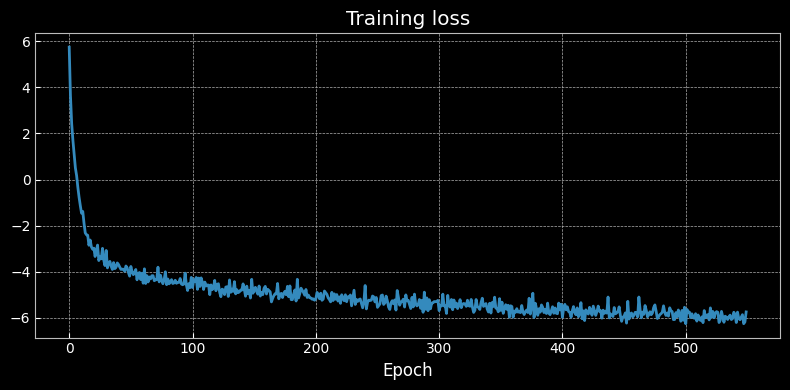

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

# Four-Panel Inference Check

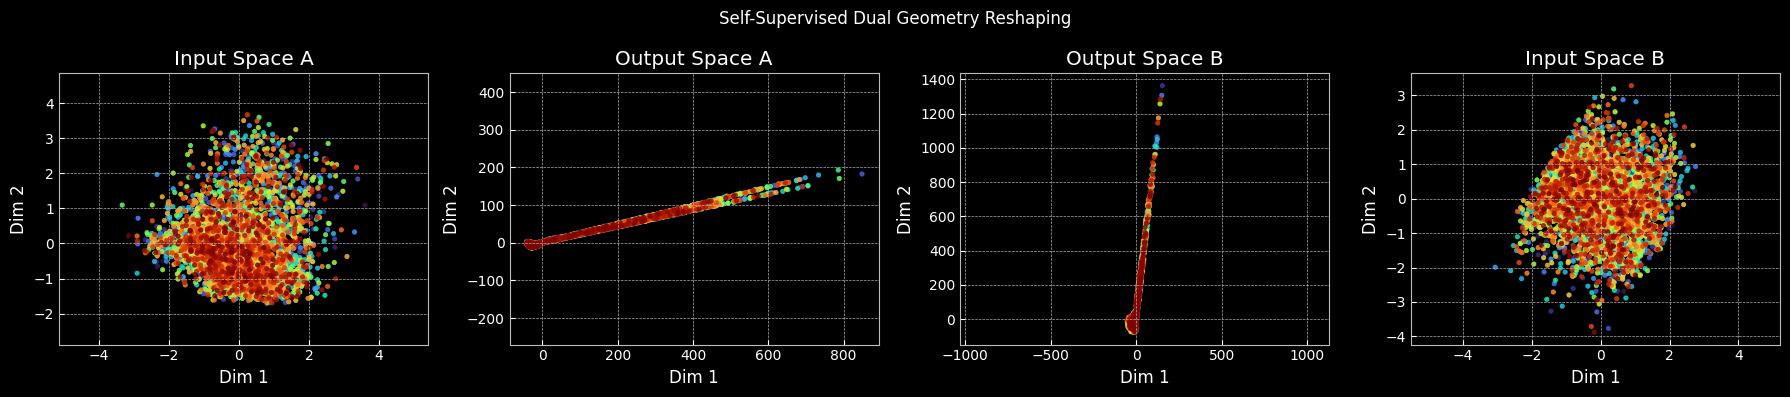

In [17]:
data_a_np = data_a if isinstance(data_a, np.ndarray) else data_a.numpy()
data_b_np = data_b if isinstance(data_b, np.ndarray) else data_b.numpy()

with torch.no_grad():
    output_a, _ = model_a(torch.tensor(data_a_np, device=device, dtype=torch.float64))
    output_b, _ = model_b(torch.tensor(data_b_np, device=device, dtype=torch.float64))

output_a = output_a.detach().cpu().numpy()
output_b = output_b.detach().cpu().numpy()
color_code = (param_values - np.min(param_values)) / (np.max(param_values) - np.min(param_values) + 1e-12)

def dual_geometry_reshaping_view(dim_1: float = None, dim_2: float = None):
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle('Self-Supervised Dual Geometry Reshaping')

    has_marker = (dim_1 is not None) and (dim_2 is not None)
    if has_marker:
        output_marker = torch.tensor([[dim_1, dim_2]], device=device, dtype=torch.float64)
        with torch.no_grad():
            input_a_marker = model_a.invert(output_marker).detach().cpu().numpy()[0]
            input_b_marker = model_b.invert(output_marker).detach().cpu().numpy()[0]

    axs[0].scatter(data_a_np[:, 0], data_a_np[:, 1], c=color_code, cmap='turbo', s=10, alpha=0.85)
    if has_marker:
        axs[0].scatter([input_a_marker[0]], [input_a_marker[1]], color='white', s=100, edgecolors='white', linewidths=1.0, zorder=5)
    axs[0].set_title('Input Space A')
    axs[0].set_xlabel('Dim 1')
    axs[0].set_ylabel('Dim 2')
    axs[0].axis('equal')

    axs[1].scatter(output_a[:, 0], output_a[:, 1], c=color_code, cmap='turbo', s=10, alpha=0.85)
    if has_marker:
        axs[1].scatter([dim_1], [dim_2], color='white', s=100, edgecolors='white', linewidths=1.0, zorder=5)
    axs[1].set_title('Output Space A')
    axs[1].set_xlabel('Dim 1')
    axs[1].set_ylabel('Dim 2')
    axs[1].axis('equal')

    axs[2].scatter(output_b[:, 0], output_b[:, 1], c=color_code, cmap='turbo', s=10, alpha=0.85)
    if has_marker:
        axs[2].scatter([dim_1], [dim_2], color='white', s=100, edgecolors='white', linewidths=1.0, zorder=5)
    axs[2].set_title('Output Space B')
    axs[2].set_xlabel('Dim 1')
    axs[2].set_ylabel('Dim 2')
    axs[2].axis('equal')

    axs[3].scatter(data_b_np[:, 0], data_b_np[:, 1], c=color_code, cmap='turbo', s=10, alpha=0.85)
    if has_marker:
        axs[3].scatter([input_b_marker[0]], [input_b_marker[1]], color='white', s=100, edgecolors='white', linewidths=1.0, zorder=5)
    axs[3].set_title('Input Space B')
    axs[3].set_xlabel('Dim 1')
    axs[3].set_ylabel('Dim 2')
    axs[3].axis('equal')

    plt.tight_layout()
    plt.show()

# interact(
#     dual_geometry_reshaping_view,
#     dim_1=(-2.0, 2.0, 0.1),
#     dim_2=(-2.0, 2.0, 0.1),
# )
dual_geometry_reshaping_view()

In [18]:
# Determine Matching and Unique Dimensions
w_a2b = predictor_a2b.weight.detach().cpu().numpy()
w_b2a = predictor_b2a.weight.detach().cpu().numpy()

threshold = 0.5
matching_dims = [i for i, w in enumerate(w_a2b) if abs(w) > threshold]
unique_dims = [i for i, w in enumerate(w_a2b) if abs(w) <= threshold]

print("Predictor A -> B weights:", np.round(w_a2b, 3))
print("Predictor B -> A weights:", np.round(w_b2a, 3))
print(f"\\nMatching (Shared) Dimensions ({len(matching_dims)}): {matching_dims}")
print(f"Space-Unique Dimensions ({len(unique_dims)}): {unique_dims}")


Predictor A -> B weights: [ 0.    -0.001  0.987]
Predictor B -> A weights: [ 0.    -0.003  1.003]
\nMatching (Shared) Dimensions (1): [2]
Space-Unique Dimensions (2): [0, 1]
